In [3]:
from collections import defaultdict

In [1]:
import numpy as np

In [4]:
def read_vocab(vocab_path):
    vocab2idx = defaultdict(lambda: len(vocab2idx))
    idx2vocab = {}
    
    with open(vocab_path, 'r') as f:
        char_vocabs = [line.strip() for line in f]
    special_words  = ['<PAD>','<UNK>']
    for c in special_words + char_vocabs:
        vocab2idx[c]
        idx2vocab[vocab2idx[c]] = c
    return vocab2idx, idx2vocab

def get_label():
    label2idx = {'o':0, 'B-PER':1, 'I-PER':2, 'B-LOC':3, 'I-LOC':4, 'B-ORG':5, 'I-ORG':6}
    idx2label = {idx:label for label, idx in label2idx.items()}
    return label2idx, idx2label

vocab2idx, idx2vocab = read_vocab('./model/chinese_L-12_H-768_A-12/vocab.txt')
label2idx, idx2label = get_label()

In [5]:
EPOCHS = 10
BATCH_SIZE = 64
EMBED_DIM = 8
HIDDEN_SIZE = 16
MAX_LEN = 100
VOCAB_SIZE = len(vocab2idx)
LABEL_NUMS = len(label2idx)
MODEL = 'bilstm_crf'#lstm bilstm_crf, bert_bilstm_crf

In [6]:
import tensorflow as tf
from collections import defaultdict
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [7]:
def read_corpus(corpus_path, vocab2idx, label2idx):
    with open(corpus_path, 'r') as f:
        lines = [line.strip() for line in f]
    datas, labels = [],[]
    sent_, tag_ = [],[]
    for line in lines:
        if line:
            char , label = line.strip().split()
            sent_.append(char)
            tag_.append(label)
        else:
            sent_ids = [vocab2idx[char] if char in vocab2idx else vocab2idx['<UNK>'] for char in sent_]
            tag_ids = [label2idx[label] if label in label2idx else 0 for label in tag_]
            datas.append(sent_ids)
            labels.append(tag_ids)
            sent_, tag_ = [],[]
    return datas, labels

In [8]:
def pad_data(train_datas, train_labels, max_len):
    train_datas = pad_sequences(train_datas, maxlen=max_len, padding='post')
    train_labels = pad_sequences(train_labels, maxlen=max_len, padding='post')
    
    if MODEL == 'lstm':
        train_labels = [to_categorical(i, num_classes=LABEL_NUMS) for i in train_labels]
        train_datas, train_labels = tf.stack(train_datas),tf.stack(train_labels)
        return train_datas, train_labels, []
    
    train_seq_lens = np.array([max_len] * len(train_labels))
    return train_datas, train_labels, train_seq_lens

In [9]:
train_datas, train_labels = read_corpus('./data/ner_data/train_data.txt', vocab2idx, label2idx)
val_datas, val_labels = read_corpus('./data/ner_data/test_data.txt', vocab2idx, label2idx)


In [10]:
train_datas, train_labels, train_seq_lens = pad_data(train_datas, train_labels, MAX_LEN)
val_datas, val_labels, val_seq_lens = pad_data(val_datas, val_labels, MAX_LEN)

In [11]:
np.shape(train_datas)

(50658, 100)

In [12]:
np.shape(val_datas)

(4631, 100)

In [14]:
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow import keras
from tensorflow.keras.layers import Layer,LSTM, Bidirectional, Embedding, Input, Dense, TimeDistributed
from keras_bert import load_trained_model_from_checkpoint
import matplotlib.pyplot as plt
import numpy as np

/Users/lhc456/miniconda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [15]:
def build_lstm():
    inputs = Input(shape=(MAX_LEN,), name='input_ids', dtype='int32')
    x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True)(inputs)
    x = LSTM(HIDDEN_SIZE, return_sequences=True)(x)
    logits = TimeDistributed(Dense(LABEL_NUMS, activation='softmax'), name='logit')(x)
    model = keras.models.Model(inputs=inputs, outputs=logits)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metircs=['accuracy'])
    return model


In [16]:
class CRF(Layer):
    def __init__(self, label_size, name='crf'):
        super(CRF, self).__init__(name=name)
        self.trans_params= tf.Variable(
        tf.random.uniform(shape=(label_size, label_size)), name='transition')
    @tf.function
    def call(self, inputs, labels, seq_lens):
        log_likelihood, self.trans_params = tfa.text.crf_log_likelihood(
        inputs, labels, seq_lens, transition_params=self.trans_params)
        loss = tf.reduce_sum(-log_likelihood)
        return loss

In [17]:
def build_bilstm_crf():
    inputs = Input(shape=(MAX_LEN,), name='input_ids', dtype='int32')
    targets = Input(shape=(MAX_LEN,), name='target_ids', dtype='int32')
    seq_lens=Input(shape=(), name='input_lens', dtype='int32')
    x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True)(inputs)
    x = Bidirectional(LSTM(HIDDEN_SIZE, return_sequences=True))(x)
    logits = TimeDistributed(Dense(LABEL_NUMS), name='logit')(x)
    loss = CRF(label_size=LABEL_NUMS)(logits, targets, seq_lens)
    model = keras.models.Model(inputs=[inputs, targets, seq_lens], outputs=loss)
    
    model.compile(loss=lambda y_true, y_pred: y_pred, optimizer='adam')
    return model

In [18]:
def get_bert():
    pretrained_path = './model/chinese_L-12_H-768_A-12'
    config_path = f'{pretrained_path}/bert_config.json'
    checkpoint_path = f'{pretrained_path}/bert_model.ckpt'
    vocab_path = f'{pretrained_path}/vocab.txt'
    model = load_trained_model_from_checkpoint(config_path, checkpoint_path, seq_len=MAX_LEN)
    return model

In [19]:
def build_bert_bilstm_crf():
    inputs = Input(shape=(MAX_LEN,), name='input_ids', dtype='int32')
    targets = Input(shape=(MAX_LEN,), name='target_ids', dtype='int32')
    seq_lens=Input(shape=(), name='input_lens', dtype='int32')
    
    pretrained_model = get_bert()
    x = pretrained_model([inputs, tf.zeros_like(inputs)])
    x = Bidrectional(LSTM(HIDDEN_SIZE, return_sequences=True))(x)
    logits = TimeDistributed(Dense(LABEL_NUMS), name='logit')(x)
    loss = CRF(label_size=LABEL_NUMS)(logits, targets, seq_lens)
    model = keras.model.Model(inputs=[inputs, targets, seq_lens], outputs=loss)
    
    model.compile(loss=lambda y_true, y_pred: y_pred, optimizer='adam')
    return model

In [20]:
def plot(model):
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    cur_history = model.history.history
    plt.plot(cur_history['loss'], label='训练损失')
    plt.plot(cur_history['val_loss'], label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [21]:
if MODEL == 'lstm':
    model = build_lstm()
    model.fit(x=train_datas, y=train_labels, 
              batch_size=BATCH_SIZE, epochs=EPOCHS, 
              validation_data=(val_datas, val_labels))
    save_path = 'model/lstm_ner'
    model.save(save_path)
elif MODEL == 'bilstm_crf':
    model = build_bilstm_crf()
    model.fit(x=[train_datas, train_labels, train_seq_lens], y=np.ones(len(train_labels)), 
                  validation_data=([val_datas, val_labels, val_seq_lens], np.ones(len(val_labels))), 
                  batch_size=BATCH_SIZE, epochs=EPOCHS)
    save_path = 'model/bilstm_crf_ner'
    model.save(save_path)
else:
    model = build_bert_bilstm_crf()
    model.fit(x=[train_datas, train_labels, train_seq_lens], y=np.ones(len(train_labels)), 
                  validation_data=([val_datas, val_labels, val_seq_lens], np.ones(len(val_labels))), 
                  batch_size=BATCH_SIZE, epochs=EPOCHS)
    checkpoint = tf.train.Checkpoint(model=model)
    checkpoint.save('model/bert_bilstm_crf_ner/bert_bilstm_crf_ner.ckpt')

2026-03-08 23:18:10.976173: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-03-08 23:18:10.976198: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-08 23:18:10.976204: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-03-08 23:18:10.976233: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-08 23:18:10.976248: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2026-03-08 23:18:14.596835: W tensorflow/core/common_runtime/type_inference.cc:339] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_BOOL
    }
  }
}

	for Tuple type infernce function 0
	while inferring type of node 'model/crf/StatefulPartitionedCall/cond_11/output/_134'
2026-03-08 23:18:14.620260: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 36/792 [>.............................] - ETA: 1:14:36 - loss: 7385.9956

KeyboardInterrupt: 

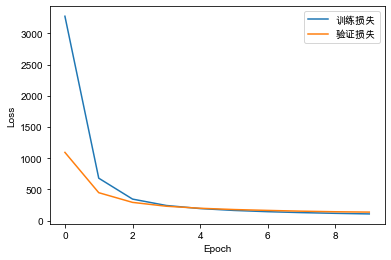

In [56]:
plot(model)

In [22]:
from tensorflow.keras import models
import tensorflow_addons as tfa
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [23]:
def predict_lstm(model, ipt):
    logits = model.predict(ipt)
    pred_seq = tf.argmax(logits, axis=-1)
    return pred_seq

In [24]:
def predict_crf(model, ipt, input_lens):
    trans_params = model.get_layer('crf').get_weights()[0]
    model_trans = models.Model(inputs=model.get_layer('input_ids').input,outputs=model.get_layer('logit').output)
    logits = model_trans.predict(ipt)
    pred_seq, viterbi_socre = tfa.text.crf_decode(logits, trans_params, input_lens)
    return pred_seq

In [25]:
def get_valid_nertag(input_data, result_tags):
    result_words = []
    start,end = 0,1
    last_tag = 'o'
    
    for i, cur_tag in enumerate(result_tags):
        if cur_tag.startswith('B'):
            if last_tag != 'o':
                result_words.append((input_data[start:end], last_tag))
            last_tag = cur_tag.split('-')[1]
            start, end = i, i + 1
        elif cur_tag.startswith('I'):
            temp_label = cur_tag.split('-')[1]
            if temp_label == last_tag: 
                end += 1
        elif cur_tag == 'o':
            if last_tag != 'o':
                result_words.append((input_data[start:end], last_tag))
                last_tag = 'o'
            start, end = i, i + 1
    if last_tag != 'o':
        result_words.append((input_data[start:end], last_Tag))
    return result_words

In [26]:
def model_test():
    sentence = '北京是中国首都，长城、天安门、故宫等都是旅游好去处。'
    sent_chars = list(sentence)
    sent2id = [vocab2idx[word] if word in vocab2idx else vocab2idx['UNK'] for word in sent_chars]
    sent2id_pad = pad_sequences([sent2id[:MAX_LEN]], maxlen=MAX_LEN, padding='post')
    
    if MODEL == 'lstm':
        #####
        pass
    elif MODEL == 'bilstm_crf':
        test_lens = np.array([MAX_LEN])
        cur_model = models.load_model('model/bilstm_crf_ner', compile=False)
        pred_seq = predict_crf(cur_model, sent2id_pad,test_lens)
    else:
        #####
        pass
    y_label = pred_seq.numpy().reshape(1, -1)[0]
    y_ner = [idx2label[i] for i in y_label][:len(sent_chars)]
    print(y_ner)
    return get_valid_nertag(sent_chars, y_ner)

In [27]:
print(f'{MODEL} test')

bilstm_crf test


In [28]:
result_words = model_test()

2026-03-08 23:22:37.154493: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2026-03-08 23:22:37.540072: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2026-03-08 23:22:37.591650: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond' has 5 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2026-03-08 23:22:37.629696: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2026-03-08 23:22:37.634407: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond' has 5 outputs but the _output_sh

1/1 [==============================] - 1s 1s/step
['B-LOC', 'I-LOC', 'o', 'B-LOC', 'I-LOC', 'o', 'o', 'o', 'B-LOC', 'I-LOC', 'o', 'B-LOC', 'I-LOC', 'I-LOC', 'o', 'B-LOC', 'I-LOC', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o']


In [29]:
for (word, tag) in result_words:
    print(''.join(word),tag)


北京 LOC
中国 LOC
长城 LOC
天安门 LOC
故宫 LOC
